# 02 — Modeling and Validation

**Evaluation protocol.** Train fits models. Validation drives model/hyperparameter selection and comparison diagnostics. **Test is not loaded in this notebook at all** — it is opened exactly once, in `03_final_test_evaluation.ipynb`, purely to report final numbers.

Two models only, both interpretable in how they're built:

- **Logistic Regression** — `ColumnTransformer` (scaling + one-hot encoding) inside an sklearn `Pipeline`, fit on train.
- **CatBoost** — native categorical-feature handling, `train` for fitting and `validation` as the early-stopping `eval_set` **during hyperparameter/model selection only**. Once hyperparameters (including the early-stopped iteration count) are frozen, the final CatBoost estimator and its probability calibration are fit using **train data only** — see Section 4 for why, and the exact procedure.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data, evaluation, modeling
from src.features import select_X_y

%matplotlib inline
pd.set_option("display.max_columns", 30)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

train = pd.read_csv(PROCESSED_DIR / "train.csv")
val = pd.read_csv(PROCESSED_DIR / "val.csv")
print("train:", train.shape, "val:", val.shape)
print("train churn rate:", train["churn_flag"].mean(), "| val churn rate:", val["churn_flag"].mean())

train: (4225, 22) val: (1409, 22)
train churn rate: 0.26532544378698225 | val churn rate: 0.2654364797728886


In [2]:
numeric_cols, categorical_cols = data.get_feature_columns(train)
feature_cols = numeric_cols + categorical_cols

X_train, y_train = select_X_y(train, feature_cols, data.TARGET)
X_val, y_val = select_X_y(val, feature_cols, data.TARGET)

## 1. Logistic Regression baseline

Class imbalance can sometimes be handled with `class_weight="balanced"`, but that is not assumed to help — it is compared against the unweighted model on validation PR-AUC, and only kept if it actually wins.

In [3]:
cw_result = modeling.choose_logreg_class_weight(
    X_train, y_train, X_val, y_val, numeric_cols, categorical_cols
)
cw_comparison = pd.DataFrame(
    {k: {"val_pr_auc": v["val_pr_auc"]} for k, v in cw_result["results"].items()}
).T
print(cw_comparison)
print("Chosen class_weight:", cw_result["best_class_weight"])

logreg_pipeline = cw_result["results"][cw_result["best_class_weight"]]["pipeline"]

          val_pr_auc
None        0.642162
balanced    0.642678
Chosen class_weight: balanced


In [4]:
logreg_val_proba = logreg_pipeline.predict_proba(X_val)[:, 1]
logreg_val_row = {"model": "Logistic Regression", **evaluation.full_comparison_row(y_val, logreg_val_proba, threshold=0.5)}
logreg_val_row

{'model': 'Logistic Regression',
 'threshold': 0.5,
 'roc_auc': 0.8363106771035159,
 'pr_auc': 0.6426775582971987,
 'precision': 0.5147826086956522,
 'recall': 0.7914438502673797,
 'f1': 0.6238145416227608,
 'tn': 756,
 'fp': 279,
 'fn': 78,
 'tp': 296,
 'brier_score': 0.16785883542704166,
 'log_loss': 0.4978239626016243}

**Coefficient inspection.** With one-hot encoding + scaling inside the pipeline, coefficients are still directly interpretable as the direction/magnitude of association with churn (in standardized-numeric / dummy-coded space).

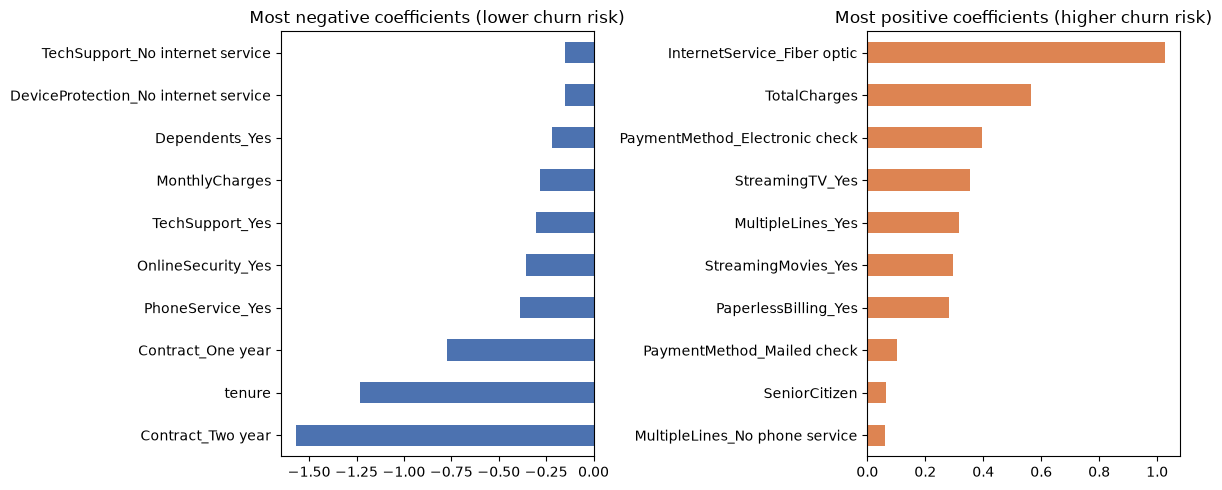

In [5]:
ohe = logreg_pipeline.named_steps["preprocess"].named_transformers_["cat"]
feature_names = numeric_cols + list(ohe.get_feature_names_out(categorical_cols))
coefs = pd.Series(logreg_pipeline.named_steps["model"].coef_[0], index=feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
coefs.head(10).plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Most negative coefficients (lower churn risk)")
coefs.tail(10).plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Most positive coefficients (higher churn risk)")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports" / "figures" / "logreg_coefficients.png", dpi=150)
plt.show()

## 2. CatBoost: small hyperparameter grid, validation-driven

A small, meaningful grid over `depth` and `learning_rate` only. Each candidate is fit on train with validation as the early-stopping `eval_set` (`eval_metric="PRAUC"`, since churners are the minority class and ranking quality is what we ultimately care about). Selection is by validation PR-AUC — never test. This is the **only** stage in the whole project where validation is used to make a model/hyperparameter decision; calibration (Section 4) deliberately does not reuse these same validation labels.

In [6]:
grid = [
    {"depth": 4, "learning_rate": 0.05},
    {"depth": 6, "learning_rate": 0.05},
    {"depth": 6, "learning_rate": 0.1},
    {"depth": 8, "learning_rate": 0.1},
]

grid_results = modeling.small_catboost_grid_search(
    X_train, y_train, X_val, y_val, feature_cols, categorical_cols, grid
)
grid_table = pd.DataFrame(
    [{**r["params"], "best_iteration": r["best_iteration"], "val_pr_auc": r["val_pr_auc"]} for r in grid_results]
)
grid_table.to_csv(TABLE_DIR / "catboost_grid_search.csv", index=False)
grid_table

,depth,learning_rate,best_iteration,val_pr_auc
0,4,0.05,192,0.652041
1,6,0.10,78,0.650383
2,8,0.10,31,0.644984
3,6,0.05,73,0.644537


In [7]:
best_params = grid_results[0]["params"]
print("Selected CatBoost params (by validation PR-AUC):", best_params)

Selected CatBoost params (by validation PR-AUC): {'depth': 4, 'learning_rate': 0.05}


**Class weighting for CatBoost.** As with Logistic Regression, we do not assume weighting the minority class helps — we compare against the unweighted best-params model on validation PR-AUC. Each candidate also gets its own early-stopped iteration count, which is carried forward as part of the "frozen" configuration in Section 4.

In [8]:
cat_unweighted = modeling.fit_catboost(
    X_train, y_train, X_val, y_val, feature_cols, categorical_cols, params=best_params
)
cat_unweighted_val_proba = cat_unweighted.predict_proba(X_val[feature_cols])[:, 1]
pr_auc_unweighted = evaluation.classification_report_dict(y_val, cat_unweighted_val_proba, 0.5)["pr_auc"]

churn_share = y_train.mean()
class_weights = [1.0, (1 - churn_share) / churn_share]
cat_weighted = modeling.fit_catboost(
    X_train, y_train, X_val, y_val, feature_cols, categorical_cols,
    params=best_params, class_weights=class_weights,
)
cat_weighted_val_proba = cat_weighted.predict_proba(X_val[feature_cols])[:, 1]
pr_auc_weighted = evaluation.classification_report_dict(y_val, cat_weighted_val_proba, 0.5)["pr_auc"]

print(f"Unweighted val PR-AUC: {pr_auc_unweighted:.4f} (best_iteration={cat_unweighted.get_best_iteration()})")
print(f"Weighted (class_weights={[round(c,2) for c in class_weights]}) val PR-AUC: {pr_auc_weighted:.4f} (best_iteration={cat_weighted.get_best_iteration()})")

if pr_auc_weighted > pr_auc_unweighted:
    chosen_class_weights = class_weights
    chosen_best_iteration = cat_weighted.get_best_iteration()
    chosen_val_proba_earlystop = cat_weighted_val_proba
    print("-> Using class-weighted CatBoost (higher validation PR-AUC).")
else:
    chosen_class_weights = None
    chosen_best_iteration = cat_unweighted.get_best_iteration()
    chosen_val_proba_earlystop = cat_unweighted_val_proba
    print("-> Using unweighted CatBoost (class weighting did not improve validation PR-AUC).")

Unweighted val PR-AUC: 0.6520 (best_iteration=192)
Weighted (class_weights=[1.0, np.float64(2.77)]) val PR-AUC: 0.6533 (best_iteration=303)
-> Using class-weighted CatBoost (higher validation PR-AUC).


## 3. Freeze hyperparameters, then fit the final estimator on train only

Hyperparameter selection (depth, learning_rate, class weighting, and the early-stopped iteration count) is now complete and used validation exactly once, for that purpose. From here on, `frozen_params` is a fixed, no-early-stopping CatBoost configuration — no further fitting step uses validation as an `eval_set` or training target.

In [9]:
frozen_params = modeling.freeze_catboost_params(
    best_params, chosen_best_iteration, class_weights=chosen_class_weights
)
print("Frozen CatBoost configuration (fixed iterations, no early stopping):")
frozen_params

Frozen CatBoost configuration (fixed iterations, no early stopping):


{'depth': 4,
 'learning_rate': 0.05,
 'iterations': 304,
 'loss_function': 'Logloss',
 'random_seed': 42,
 'verbose': False,
 'class_weights': [1.0, np.float64(2.7689562890276536)]}

In [10]:
cat_uncalibrated = modeling.fit_frozen_catboost(X_train[feature_cols], y_train, categorical_cols, frozen_params)
cat_uncal_val_proba = cat_uncalibrated.predict_proba(X_val[feature_cols])[:, 1]

## 4. Probability calibration — fit by cross-validation on train, never on validation

**Why not calibrate on validation, as a first draft of this project did:** validation is also used above to select hyperparameters and, in `04_retention_decisioning.ipynb`, would otherwise be the obvious place to *evaluate* any policy built from these probabilities. Fitting the calibration map on the same validation labels used for those decisions is a form of double-use of the same data — it does not leak test, but it blurs the boundary between "data used to build the model" and "data used to independently check it."

**The fix, `TrainCVCalibratedCatBoost` in `src/modeling.py`:**
1. Split train into 5 stratified folds.
2. For each fold, fit a fresh CatBoost model (the frozen hyperparameters above, no early stopping) on the other folds and predict on the held-out fold — producing out-of-fold (OOF) probabilities the model never saw during its own training.
3. Fit a sigmoid (logistic regression) calibration map on those OOF probabilities vs. the true training labels.
4. Refit CatBoost once on the full training set for the strongest final model, and apply the calibration map to its predictions at inference time.

Validation is used only to **evaluate** (never fit) this calibration, alongside the uncalibrated model, as a diagnostic. Test remains completely untouched.

(`sklearn.calibration.CalibratedClassifierCV` was tried first and rejected: it calls `sklearn.base.clone()` internally, and CatBoost's sklearn wrapper does not round-trip `cat_features` cleanly enough to satisfy scikit-learn's clone check under the scikit-learn version pinned in `requirements.txt`.)

In [11]:
cat_calibrated = modeling.calibrate_via_train_cv(
    X_train[feature_cols], y_train, categorical_cols, frozen_params, method="sigmoid", cv=5
)
cat_cal_val_proba = cat_calibrated.predict_proba(X_val[feature_cols])[:, 1]

In [12]:
brier_before = evaluation.calibration_summary(y_val, cat_uncal_val_proba)
brier_after = evaluation.calibration_summary(y_val, cat_cal_val_proba)
print("CatBoost validation calibration BEFORE calibration (diagnostic only):", brier_before)
print("CatBoost validation calibration AFTER train-CV calibration (diagnostic only):", brier_after)

pd.DataFrame([
    {"stage": "raw (frozen, train-fit)", **brier_before},
    {"stage": "calibrated (train-CV)", **brier_after},
]).to_csv(TABLE_DIR / "calibration_decision.csv", index=False)

CatBoost validation calibration BEFORE calibration (diagnostic only): {'brier_score': 0.16591757276900546, 'log_loss': 0.49179781137163925}
CatBoost validation calibration AFTER train-CV calibration (diagnostic only): {'brier_score': 0.13764518983720367, 'log_loss': 0.4264017151099797}


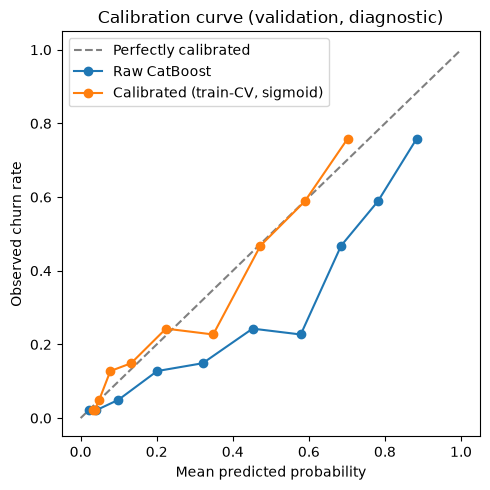

In [13]:
cal_curve_before = evaluation.calibration_table(y_val, cat_uncal_val_proba)
cal_curve_after = evaluation.calibration_table(y_val, cat_cal_val_proba)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
ax.plot(cal_curve_before["mean_predicted_prob"], cal_curve_before["fraction_of_positives"], marker="o", label="Raw CatBoost")
ax.plot(cal_curve_after["mean_predicted_prob"], cal_curve_after["fraction_of_positives"], marker="o", label="Calibrated (train-CV, sigmoid)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title("Calibration curve (validation, diagnostic)")
ax.legend()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports" / "figures" / "calibration_curve_validation.png", dpi=150)
plt.show()

Class weighting distorts CatBoost's raw probabilities away from the true churn rate (that is expected — the loss function was reweighted, so the probabilities are no longer a direct MLE of churn likelihood). Calibration exists specifically to correct this before the probabilities are used in the economics model in notebook 04. **The calibrated model is used as the final model regardless of this diagnostic's outcome** — calibration is part of the fixed protocol (Section 4 above), not a validation-scored choice — but the diagnostic is reported honestly either way.

## 5. Validation-set model comparison (diagnostic)

In [14]:
cat_val_row = {"model": "CatBoost (calibrated)", **evaluation.full_comparison_row(y_val, cat_cal_val_proba, 0.5)}
val_comparison = pd.DataFrame([logreg_val_row, cat_val_row]).set_index("model")
val_comparison.to_csv(TABLE_DIR / "validation_model_comparison.csv")
val_comparison

,threshold,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp,brier_score,log_loss
model,,,,,,,,,,,,
Logistic Regression,0.5,0.836311,0.642678,0.514783,0.791444,0.623815,756,279,78,296,0.167859,0.497824
CatBoost (calibrated),0.5,0.839230,0.653307,0.653251,0.564171,0.605452,923,112,163,211,0.137645,0.426402


In [15]:
logreg_val_ranking = evaluation.ranking_table(y_val, logreg_val_proba)
logreg_val_ranking.insert(0, "model", "Logistic Regression")

cat_val_ranking = evaluation.ranking_table(y_val, cat_cal_val_proba)
cat_val_ranking.insert(0, "model", "CatBoost (calibrated)")

val_ranking = pd.concat([logreg_val_ranking, cat_val_ranking], ignore_index=True)
val_ranking.to_csv(TABLE_DIR / "validation_ranking_comparison.csv", index=False)
val_ranking

,model,top_k_pct,n_contacted,churners_captured,precision_at_k,recall_at_k,lift_at_k
0,Logistic Regression,5.0,70,52,0.742857,0.139037,2.798625
1,Logistic Regression,10.0,141,103,0.730496,0.275401,2.752057
2,Logistic Regression,20.0,282,193,0.684397,0.516043,2.578384
3,CatBoost (calibrated),5.0,70,59,0.842857,0.157754,3.175363
4,CatBoost (calibrated),10.0,141,107,0.758865,0.286096,2.858934
5,CatBoost (calibrated),20.0,282,190,0.673759,0.508021,2.538305


## 6. Persist the final chosen pipeline

`catboost_final.pkl` is the train-CV-calibrated model (Section 4): its base CatBoost component was fit on train only, and its calibration map was fit on out-of-fold train predictions only — validation and test were both untouched by this fitting process. `catboost_uncalibrated.pkl` (the frozen, uncalibrated model fit once on all of train) is kept for SHAP and as the before/after calibration baseline in notebook 03.

In [16]:
import joblib

joblib.dump(cat_calibrated, MODEL_DIR / "catboost_final.pkl")
joblib.dump(cat_uncalibrated, MODEL_DIR / "catboost_uncalibrated.pkl")
joblib.dump(logreg_pipeline, MODEL_DIR / "logreg_final.pkl")

with open(MODEL_DIR / "feature_columns.txt", "w") as f:
    f.write("\n".join(feature_cols))

print("Saved calibrated CatBoost, uncalibrated CatBoost, and Logistic Regression pipelines to", MODEL_DIR)

Saved calibrated CatBoost, uncalibrated CatBoost, and Logistic Regression pipelines to C:\Users\grosh\subscription-churn-model\models


## Summary

- Logistic Regression and CatBoost were both fit on train only; hyperparameter and class-weighting decisions used validation exclusively, and only once.
- CatBoost's small `depth` x `learning_rate` grid was selected by validation PR-AUC with early stopping against the validation `eval_set` (test was never involved).
- Once hyperparameters were frozen, the final CatBoost estimator and its sigmoid calibration were fit using **train-only, out-of-fold cross-validation** — not validation — so validation remains free for model comparison and diagnostics without any double-use of the same labels.
- Validation-set comparison (diagnostic only) now includes Brier score and log loss alongside ROC-AUC/PR-AUC/ranking metrics, ahead of the final head-to-head on test in notebook 03.
- The final artifacts (`models/catboost_final.pkl`, `models/logreg_final.pkl`) are evaluated exactly once, on test, in `03_final_test_evaluation.ipynb`.